# ML Regression from Scratch - Notebook 4: Polynomial Regression (Full Dataset) + Cross-Validation

**Goal:** extend previous five-feature linear model to **polynomial**
features, use **k-fold cross-validation** (implemented from scratch) to
choose the best degree without touching the test set, then evaluate the
chosen model on the held-out test set - all with NumPy only.

Same five mapped features:
`Attendance`, `TotalHours`, `AssignmentsCompleted`, `GitHubScore`, `PeerReviewScore`
→ target `CapstoneScore`.

**How "polynomial with 5 features" is defined here.** Full interaction
terms (e.g. $x_1 x_2$, $x_1^2 x_3$, ...) would explode combinatorially -
degree 3 with 5 features and all cross-terms is dozens of columns for only
~70 rows of data, which is a recipe for severe overfitting before we've
even started. Instead we extend **each feature independently** to its own
powers, i.e. for degree $d$ every feature $x_j$ contributes columns
$x_j, x_j^2, \dots, x_j^d$ (no cross-products). This keeps the parameter
count reasonable (5×degree + 1) while still letting each feature bend
non-linearly.

We will:
1. Reload data, features, and the train/test split from Notebook 3
2. Implement multi-feature `create_polynomial_features`
3. Implement k-fold cross-validation from scratch
4. Use CV (on the training set only) to compare degrees 1, 2, 3
5. Refit the best degree on the full training set and evaluate on the test set

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load data & recreate the Notebook 3 split

In [4]:
df = pd.read_csv('student scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)

feature_cols = ['Attendance', 'TotalHours', 'AssignmentsCompleted', 'GitHubScore', 'PeerReviewScore']
target_col = 'CapstoneScore'

X = df[feature_cols].values.astype(float)
Y = df[target_col].values.astype(float)

def train_test_split_scratch(X, Y, test_size=0.2, seed=42):
    m = len(Y)
    rng = np.random.RandomState(seed)
    shuffled_idx = rng.permutation(m)
    n_test = int(m * test_size)
    test_idx = shuffled_idx[:n_test]
    train_idx = shuffled_idx[n_test:]
    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]

X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.2, seed=42)
print(f"X_train: {X_train.shape},  X_test: {X_test.shape}")

X_train: (58, 5),  X_test: (14, 5)


## 2. Multi-feature polynomial features

Extends Notebook 2's `create_polynomial_features` from a single column to
a full feature matrix: for every input feature, append its powers
$1..degree$. Column order for degree $d$: all features to power 1, then
all features to power 2, ..., up to power $d$.

In [5]:
def create_polynomial_features(X, degree):
    """
    Expand every column of a feature matrix to its own powers (no
    cross-terms between different features).

    X      : (m, n_features) raw feature matrix
    degree : highest power per feature

    Returns an (m, n_features * degree) matrix:
      [x1, x2, ..., xn,  x1^2, x2^2, ..., xn^2,  ...,  x1^degree, ..., xn^degree]
    """
    m, n_features = X.shape
    X_poly = np.zeros((m, n_features * degree))
    for d in range(1, degree + 1):
        start = (d - 1) * n_features
        X_poly[:, start:start + n_features] = X ** d
    return X_poly


# Sanity check: degree 1 should just reproduce the original features
np.allclose(create_polynomial_features(X_train, degree=1), X_train)

True

## 3. Standardizing, bias, cost/gradient — same building blocks as Notebooks 1-3

In [6]:
def standardize_features(X, mu=None, sigma=None):
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma

def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])

def compute_cost(X_design, y, theta):
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)

def compute_gradients(X_design, y, theta):
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / m) * X_design.T.dot(y_hat - y)

def gradient_descent(X_design, y, learning_rate, n_iterations=3000, theta_init=None):
    n = X_design.shape[1]
    theta = np.zeros(n) if theta_init is None else theta_init
    cost_history = []
    for i in range(n_iterations):
        cost = compute_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_gradients(X_design, y, theta)
    return theta, cost_history

def predict(X_design, theta):
    return X_design.dot(theta)

def fit_polynomial(X, y, degree, learning_rate, n_iterations=3000):
    """
    Full pipeline: raw multi-feature X -> polynomial expansion ->
    standardize -> add bias -> gradient descent.
    Returns theta, cost_history, mu, sigma.
    """
    X_poly = create_polynomial_features(X, degree)
    X_scaled, mu, sigma = standardize_features(X_poly)
    X_design = add_bias(X_scaled)
    theta, cost_history = gradient_descent(X_design, y, learning_rate, n_iterations)
    return theta, cost_history, mu, sigma

def predict_polynomial(X, theta, degree, mu, sigma):
    X_poly = create_polynomial_features(X, degree)
    X_scaled, _, _ = standardize_features(X_poly, mu, sigma)
    X_design = add_bias(X_scaled)
    return predict(X_design, theta)

## 4. Evaluation metrics

In [7]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def evaluate(y_true, y_pred):
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

## 5. K-fold cross-validation, from scratch

Cross-validation gives a more reliable estimate of "how will this degree
generalize?" than a single train/validation split, because every row gets
to be in the validation fold exactly once. Crucially, **cross-validation
runs entirely inside the training set** — the test set stays untouched
until the very end, so our degree choice can't be biased by test-set
performance.

Steps: shuffle the training row indices once, cut them into $k$
(roughly) equal folds, then for each fold: train on the other $k-1$
folds, validate on the held-out fold, and record its metrics. Scaling
statistics (`mu`, `sigma`) are re-fit on each fold's training portion
only — never on the validation fold.

In [8]:
def k_fold_indices(m, k=5, seed=42):
    """Return a list of k arrays of row indices (a partition of 0..m-1)."""
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(m)
    return np.array_split(shuffled, k)


def cross_validate_polynomial(X, y, degree, learning_rate, n_iterations=3000, k=5, seed=42):
    """
    k-fold CV for a given polynomial degree.

    Returns:
        avg_metrics  : dict of MSE/RMSE/MAE/R2 averaged across the k folds
        fold_metrics : list of the k individual per-fold metric dicts
    """
    folds = k_fold_indices(len(y), k=k, seed=seed)
    fold_metrics = []

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

        X_fold_train, X_fold_val = X[train_idx], X[val_idx]
        y_fold_train, y_fold_val = y[train_idx], y[val_idx]

        theta, _, mu, sigma = fit_polynomial(X_fold_train, y_fold_train, degree, learning_rate, n_iterations)
        y_pred_val = predict_polynomial(X_fold_val, theta, degree, mu, sigma)

        fold_metrics.append(evaluate(y_fold_val, y_pred_val))

    avg_metrics = {m: np.mean([fm[m] for fm in fold_metrics]) for m in fold_metrics[0]}
    return avg_metrics, fold_metrics

## 6. Compare degrees 1, 2, 3 with 5-fold CV (training set only)

In [9]:
degrees = [1, 2, 3]
LEARNING_RATE = 0.1
N_ITERATIONS = 2000
K_FOLDS = 5

cv_results = {}
for degree in degrees:
    avg_metrics, fold_metrics = cross_validate_polynomial(
        X_train, Y_train, degree, LEARNING_RATE, N_ITERATIONS, k=K_FOLDS, seed=42
    )
    cv_results[degree] = {'avg': avg_metrics, 'folds': fold_metrics}
    fold_r2s = [f['R2'] for f in fold_metrics]
    print(f"degree={degree} | CV mean R2={avg_metrics['R2']:.4f} (fold R2s: {[round(r,3) for r in fold_r2s]}) "
          f"| CV mean RMSE={avg_metrics['RMSE']:.4f}")

degree=1 | CV mean R2=0.8931 (fold R2s: [np.float64(0.936), np.float64(0.881), np.float64(0.72), np.float64(0.963), np.float64(0.966)]) | CV mean RMSE=4.8042
degree=2 | CV mean R2=0.8935 (fold R2s: [np.float64(0.946), np.float64(0.883), np.float64(0.705), np.float64(0.961), np.float64(0.972)]) | CV mean RMSE=4.7081
degree=3 | CV mean R2=0.8938 (fold R2s: [np.float64(0.953), np.float64(0.88), np.float64(0.706), np.float64(0.962), np.float64(0.968)]) | CV mean RMSE=4.7018


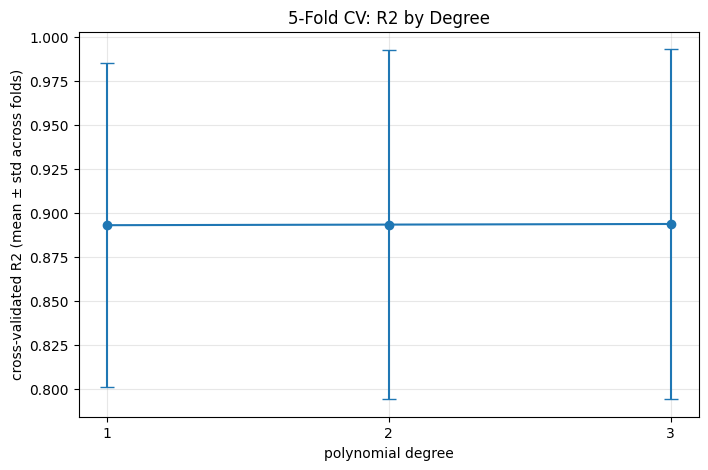

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [cv_results[d]['avg']['R2'] for d in degrees]
stds = [np.std([f['R2'] for f in cv_results[d]['folds']]) for d in degrees]
ax.errorbar(degrees, means, yerr=stds, fmt='o-', capsize=5, color='tab:blue')
ax.set_xlabel('polynomial degree')
ax.set_ylabel('cross-validated R2 (mean ± std across folds)')
ax.set_xticks(degrees)
ax.set_title(f'{K_FOLDS}-Fold CV: R2 by Degree')
ax.grid(alpha=0.3)
plt.show()

## 7. Pick the best degree and confirm on the held-out test set

We choose the degree with the best **CV** R² (not test R² — the test set
must only be looked at once, at the end, or it stops being a fair final
check).

In [11]:
best_degree = max(degrees, key=lambda d: cv_results[d]['avg']['R2'])
print(f"Degree selected by cross-validation: {best_degree}")

# Refit on the FULL training set (all folds combined) at the chosen degree
theta_final, cost_history_final, mu_final, sigma_final = fit_polynomial(
    X_train, Y_train, best_degree, LEARNING_RATE, n_iterations=3000
)

y_pred_train_final = predict_polynomial(X_train, theta_final, best_degree, mu_final, sigma_final)
y_pred_test_final = predict_polynomial(X_test, theta_final, best_degree, mu_final, sigma_final)

final_train_metrics = evaluate(Y_train, y_pred_train_final)
final_test_metrics = evaluate(Y_test, y_pred_test_final)

final_df = pd.DataFrame(
    [cv_results[best_degree]['avg'], final_train_metrics, final_test_metrics],
    index=[f'CV mean (degree {best_degree})', 'full train fit', 'held-out test']
)
final_df.round(4)

Degree selected by cross-validation: 3


,MSE,RMSE,MAE,R2
CV mean (degree 3),24.2778,4.7018,3.7740,0.8938
full train fit,17.6081,4.1962,3.0915,0.9450
held-out test,27.4225,5.2366,4.5261,0.7727


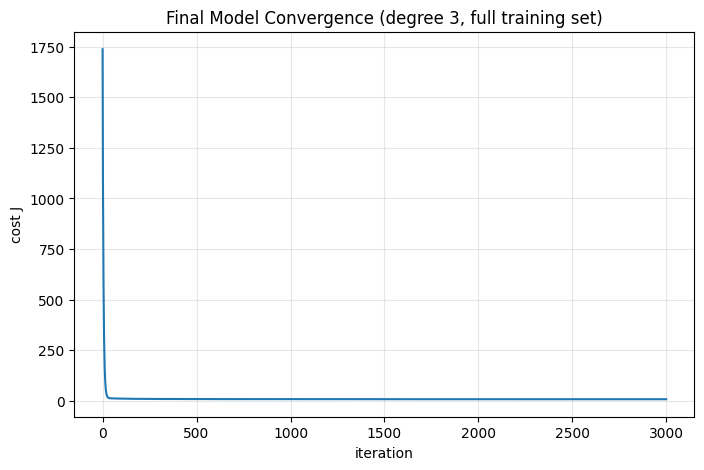

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history_final)
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title(f"Final Model Convergence (degree {best_degree}, full training set)")
plt.grid(alpha=0.3)
plt.show()

## 8. Degree comparison: CV vs. train vs. test, side by side

Putting all three numbers together for every degree is the clearest way
to see overfitting: training error should keep improving with degree,
while CV/test error tells us whether that improvement is real or just
memorization.

In [13]:
comparison_rows = []
for degree in degrees:
    theta_d, _, mu_d, sigma_d = fit_polynomial(X_train, Y_train, degree, LEARNING_RATE, n_iterations=3000)
    train_r2_d = evaluate(Y_train, predict_polynomial(X_train, theta_d, degree, mu_d, sigma_d))['R2']
    test_r2_d = evaluate(Y_test, predict_polynomial(X_test, theta_d, degree, mu_d, sigma_d))['R2']
    cv_r2_d = cv_results[degree]['avg']['R2']

    comparison_rows.append({
        'degree': degree,
        'n_parameters': degree * len(feature_cols) + 1,
        'train_R2': round(train_r2_d, 4),
        'CV_R2': round(cv_r2_d, 4),
        'test_R2': round(test_r2_d, 4),
    })

degree_comparison_df = pd.DataFrame(comparison_rows)
degree_comparison_df

,degree,n_parameters,train_R2,CV_R2,test_R2
0,1,6,0.9335,0.8931,0.8024
1,2,11,0.9418,0.8935,0.7861
2,3,16,0.9450,0.8938,0.7727


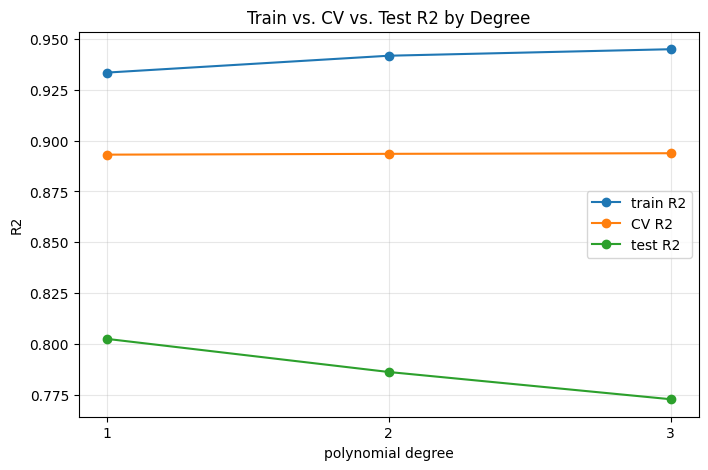

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(degree_comparison_df['degree'], degree_comparison_df['train_R2'], 'o-', label='train R2')
plt.plot(degree_comparison_df['degree'], degree_comparison_df['CV_R2'], 'o-', label='CV R2')
plt.plot(degree_comparison_df['degree'], degree_comparison_df['test_R2'], 'o-', label='test R2')
plt.xlabel('polynomial degree')
plt.ylabel('R2')
plt.xticks(degrees)
plt.title('Train vs. CV vs. Test R2 by Degree')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Reading this chart

- If **train R²** rises steadily with degree while **CV R²** flattens or
  falls, the model is overfitting past that point — more parameters are
  fitting training noise rather than generalizable signal. With
  `n_parameters = 5 × degree + 1` and only ~46 rows per CV training fold,
  degree 3 (16 parameters) has a real risk of this on a dataset this small.
- **Test R²** is reported only for the CV-selected degree and for
  completeness across all degrees here — but the degree *choice* itself
  was made using CV alone, so the test number is an honest, unbiased final
  check rather than something we picked to look good.
- If CV and test R² agree reasonably well for the chosen degree, that's
  good evidence the cross-validation procedure did its job.

## 9. Takeaways

- Cross-validation, implemented here as plain `k_fold_indices` +
  `cross_validate_polynomial`, gives a degree-selection process that never
  touches the test set — the same discipline a real ML workflow requires,
  without needing scikit-learn's `cross_val_score`.
- Expanding each feature to its own powers (rather than full
  interactions) keeps the parameter count linear in the number of
  features, which matters a lot on a ~70-row dataset where every extra
  parameter is expensive in terms of overfitting risk.
- The train / CV / test R² comparison is the clearest tool we have for
  telling "this extra flexibility helped" apart from "this extra
  flexibility just memorized noise" — exactly the judgment call the
  assignment asks for.